In [1]:
! pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 47.8 MB/s eta 0:00:00


In [2]:
"""
MAE-based Unsupervised Anomaly Detection for FCD (Focal Cortical Dysplasia)
===========================================================================
Pipeline:
  1. Train MaskedAutoEncoderViT on healthy (HC) MRI volumes only
  2. At inference, reconstruct lesion (FCD) volumes
  3. Compute residual map — lesion appears as high-error region
  4. Threshold residual to get binary lesion mask
  5. Evaluate against ground-truth masks
"""

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from glob import glob
from scipy import ndimage
from einops import rearrange
import torch.nn.functional as F
 
from monai.networks.nets.masked_autoencoder_vit import MaskedAutoEncoderViT
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd,
    NormalizeIntensityd, ResizeWithPadOrCropd, EnsureTyped,
    RandFlipd, RandAffined, RandGaussianNoised, RandAdjustContrastd,
    SpatialPadd, RandSpatialCropd,
)
from monai.data import CacheDataset, DataLoader, Dataset

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-13 20:29:26.653118: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778704167.067693      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778704167.187432      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778704168.280321      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778704168.280374      23 computation_placer.cc:1

In [3]:
# =============================================================================
# 0. CONFIG
# =============================================================================
IMG_SIZE      = 96
PATCH_SIZE    = 8
BATCH_SIZE    = 2
NUM_EPOCHS    = 2000
LR            = 1e-5
WEIGHT_DECAY  = 0.005
WARMUP_EPOCHS = 0.05 * NUM_EPOCHS
MASKING_RATIO = 0.85
SAVE_PATH     = "mae_best_model_updated.pth"
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# =============================================================================
# 1. DATA LOADING
# =============================================================================
data_root = '/kaggle/input/datasets/almadavidson1/fcd-database'
tsv_path  = os.path.join(data_root, "participants.tsv")
df        = pd.read_csv(tsv_path, sep='\t')
 
data_dicts = []
for idx, row in df.iterrows():
    p_id = row['participant_id']
 
    image_pattern = os.path.join(data_root, 'DATA', p_id, 'anat', f"*_T1w.nii*", f"*_T1w.nii*")
    img_files     = glob(image_pattern)
 
    mask_pattern  = os.path.join(data_root, 'DATA', p_id, 'anat', f"*-FLAIR_roi_inT1.nii*")
    mask_files   = glob(mask_pattern)
 
    if img_files:
        entry = {"image": img_files[0], "group": row.get('group', 'hc')}
        if mask_files:
            entry["mask"] = mask_files[0]
        data_dicts.append(entry)
 
hc_dict       = [d for d in data_dicts if str(d['group']).lower() == 'hc']
fcd_dict      = [d for d in data_dicts if str(d['group']).lower() == 'fcd' and 'mask' in d]
fcd_dict_clean = [d for d in fcd_dict if os.path.getsize(d["mask"]) > 0]
 
print(f"HC subjects:             {len(hc_dict)}")
print(f"FCD subjects with mask:  {len(fcd_dict_clean)}")
 
# Training on healthy only; val on remaining healthy + all FCD
train_files = hc_dict[:75]
val_hc      = hc_dict[75:]

HC subjects:             85
FCD subjects with mask:  85


In [5]:
# =============================================================================
# 2. TRANSFORMS
# =============================================================================
base_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    SpatialPadd(keys=["image"], spatial_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE)),
])

aug_transforms = Compose([
    RandSpatialCropd(keys=["image"], roi_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE), random_size=False),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
    RandAffined(
        keys=["image"], prob=0.3,
        rotate_range=(0.15, 0.15, 0.15),
        scale_range=(0.1, 0.1, 0.1),
        mode="bilinear", padding_mode="border",
    ),
    RandGaussianNoised(keys=["image"], prob=0.2, std=0.05),
    RandAdjustContrastd(keys=["image"], prob=0.3, gamma=(0.7, 1.5)),
    EnsureTyped(keys=["image"], dtype=torch.float32),
])
 

val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    SpatialPadd(keys=["image"], spatial_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE)),
    RandSpatialCropd(keys=["image"], roi_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE), random_size=False),
    EnsureTyped(keys=["image"], dtype=torch.float32),
])

fcd_transforms = Compose([
    LoadImaged(keys=["image","mask"]),
    EnsureChannelFirstd(keys=["image","mask"]),
    Orientationd(keys=["image","mask"], axcodes="RAS"),
    NormalizeIntensityd(keys=["image","mask"], nonzero=True, channel_wise=True),
    EnsureTyped(keys=["image","mask"], dtype=torch.float32),
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [6]:
# =============================================================================
# 3. DATASETS & DATALOADERS
# =============================================================================
base_ds = CacheDataset(
    data=train_files,
    transform=base_transforms,
    cache_rate=1.0,
    num_workers=4
)
train_ds = Dataset(
    data=base_ds, 
    transform=aug_transforms
)
val_ds   = CacheDataset(data=val_hc,     transform=val_transforms,
                        cache_rate=1.0, num_workers=2)
fcd_ds   = Dataset(data=fcd_dict_clean, transform=fcd_transforms)
 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1,          shuffle=False,
                          num_workers=2)
fcd_loader   = DataLoader(fcd_ds,   batch_size=1,          shuffle=False,
                          num_workers=2)
 
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | FCD cases: {len(fcd_ds)}")

Loading dataset: 100%|██████████| 10/10 [00:11<00:00,  1.14s/it]

Train batches: 38 | Val batches: 10 | FCD cases: 85


In [7]:
# =============================================================================
# 4. MODEL
# =============================================================================
model = MaskedAutoEncoderViT(
    spatial_dims=3,
    in_channels=1,
    img_size=(IMG_SIZE, IMG_SIZE, IMG_SIZE),
    patch_size=(PATCH_SIZE, PATCH_SIZE, PATCH_SIZE),
    masking_ratio=MASKING_RATIO,
).to(DEVICE)

pre_weights = "/kaggle/input/datasets/almadavidson/pretrained-weights/mae_best_model.pth"
model.load_state_dict(torch.load(pre_weights)['model_state_dict'])
 
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params / 1e6:.1f}M")

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Model parameters: 73.3M


In [8]:
# =============================================================================
# 5. LOSS, OPTIMIZER, SCHEDULER
# =============================================================================
 
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),   # MAE paper recommendation — 0.95 not default 0.999
)
 
# Warmup → Cosine annealing
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
 
warmup_scheduler = LinearLR(
    optimizer,
    start_factor=1e-3,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS,
)
cosine_scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS - WARMUP_EPOCHS,
    eta_min=1e-6,
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[WARMUP_EPOCHS],
)
 

In [9]:
# =============================================================================
# 6. TRAINING HELPERS
# =============================================================================
GRID = IMG_SIZE // PATCH_SIZE   # 6
 
def patchify(x):
    """(B, 1, H, W, D) → (B, N_patches, patch_volume)"""
    return rearrange(
        x, 'b c (h p1) (w p2) (d p3) -> b (h w d) (p1 p2 p3 c)',
        p1=PATCH_SIZE, p2=PATCH_SIZE, p3=PATCH_SIZE
    )
 
def unpatchify(patches):
    """(B, N_patches, patch_volume) → (B, 1, H, W, D)"""
    return rearrange(
        patches,
        'b (h w d) (p1 p2 p3 c) -> b c (h p1) (w p2) (d p3)',
        h=GRID, w=GRID, d=GRID,
        p1=PATCH_SIZE, p2=PATCH_SIZE, p3=PATCH_SIZE, c=1
    )
 
def compute_loss(x, pred, mask):
    """
    Combined MSE (masked patches only) + SSIM (full image).
    pred:  (B, N_patches, patch_volume)
    mask:  (B, N_patches)  — 1 = masked, 0 = visible
    """
    target = patchify(x)
 
    # MSE only on masked patches
    loss_per_pixel = F.mse_loss(pred, target, reduction="none")
    loss_per_patch = loss_per_pixel.mean(dim=-1)
    mse_loss       = (loss_per_patch * mask).sum() / mask.sum()
 
    # Reconstruct full image
    composed_patches = pred * mask.unsqueeze(-1) + target * (1 - mask.unsqueeze(-1))
    composed         = unpatchify(composed_patches)
    #ssim_loss        = ssim_loss_fn(composed, x)
 
    return mse_loss, composed

In [10]:
# =============================================================================
# 7. TRAINING LOOP
# =============================================================================
best_val_loss  = float("inf")
train_losses   = []
val_losses     = []
 
# Fixed healthy volume for visual monitoring every 10 epochs
viz_volume = next(iter(val_loader))["image"][[0]].to(DEVICE)
 
epoch_bar = tqdm.tqdm(range(NUM_EPOCHS), desc="MAE Pre-training", unit="epoch")
 
for epoch in epoch_bar:
 
    # ── TRAIN ──────────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0
    optimizer.zero_grad()
 
    for batch in train_loader:
        x = batch["image"].to(DEVICE)
 
        pred, mask   = model(x)
        x_patch = patchify(x)
        loss = F.mse_loss(x_patch[mask.bool()],pred[mask.bool()])
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
 
        epoch_train_loss += loss.item()
 
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
 
    # ── VALIDATE ───────────────────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0
 
    with torch.no_grad():
        for batch in val_loader:
            x            = batch["image"].to(DEVICE)
            pred, mask   = model(x)
            x_patch      = patchify(x)
            loss         = F.mse_loss(x_patch[mask.bool()],pred[mask.bool()])
            epoch_val_loss += loss.item()
 
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
 
    scheduler.step()
 
    epoch_bar.set_postfix({
        "train": f"{avg_train_loss:.5f}",
        "val":   f"{avg_val_loss:.5f}",
        "lr":    f"{optimizer.param_groups[0]['lr']:.2e}",
    })
 
    # ── CHECKPOINT ─────────────────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            "epoch":               epoch + 1,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_loss":            best_val_loss,
            "train_losses":        train_losses,
            "val_losses":          val_losses,
        }, SAVE_PATH)
        epoch_bar.write(f"  ✓ Epoch {epoch+1}: saved best model  (val={best_val_loss:.5f})")
 
    # ── VISUAL MONITORING every 10 epochs ──────────────────────────────────
    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            viz_pred, viz_mask = model(viz_volume)
            viz_composed = unpatchify(
                viz_pred * viz_mask.unsqueeze(-1) + 
                patchify(viz_volume) * (1 - viz_mask.unsqueeze(-1))
            )
 
        orig_np  = viz_volume.squeeze().cpu().numpy()
        recon_np = viz_composed.squeeze().cpu().numpy()
        resid_np = np.abs(orig_np - recon_np)
        s        = orig_np.shape[2] // 2   # central axial slice
 
        fig, axes = plt.subplots(1, 3, figsize=(13, 4))
        axes[0].imshow(orig_np[:, :, s],  cmap="gray"); axes[0].set_title("Original (HC)")
        axes[1].imshow(recon_np[:, :, s], cmap="gray"); axes[1].set_title("Reconstruction")
        axes[2].imshow(resid_np[:, :, s], cmap="hot");  axes[2].set_title("Residual")
        for ax in axes: ax.axis("off")
        plt.suptitle(f"Epoch {epoch+1}  |  train={avg_train_loss:.4f}  val={avg_val_loss:.4f}")
        plt.tight_layout()
        plt.savefig(f"recon_epoch_{epoch+1:04d}.png", dpi=100)
        plt.close()
        epoch_bar.write(f"  📊 Epoch {epoch+1}: reconstruction plot saved")
 
print(f"\nTraining complete. Best val loss: {best_val_loss:.5f}")

MAE Pre-training:   0%|          | 1/2000 [00:14<8:15:40, 14.88s/epoch, train=0.19538, val=0.24071, lr=1.10e-07]

  ✓ Epoch 1: saved best model  (val=0.24071)


MAE Pre-training:   0%|          | 2/2000 [00:28<7:47:31, 14.04s/epoch, train=0.19108, val=0.15739, lr=2.10e-07]

  ✓ Epoch 2: saved best model  (val=0.15739)


MAE Pre-training:   0%|          | 3/2000 [00:42<7:42:37, 13.90s/epoch, train=0.19463, val=0.14619, lr=3.10e-07]

...

  📊 Epoch 1980: reconstruction plot saved


MAE Pre-training: 100%|█████████▉| 1990/2000 [7:51:25<02:24, 14.49s/epoch, train=0.15316, val=0.18089, lr=1.00e-06]

  📊 Epoch 1990: reconstruction plot saved


MAE Pre-training: 100%|██████████| 2000/2000 [7:53:47<00:00, 14.21s/epoch, train=0.14298, val=0.14923, lr=1.00e-06]

  📊 Epoch 2000: reconstruction plot saved

Training complete. Best val loss: 0.09379


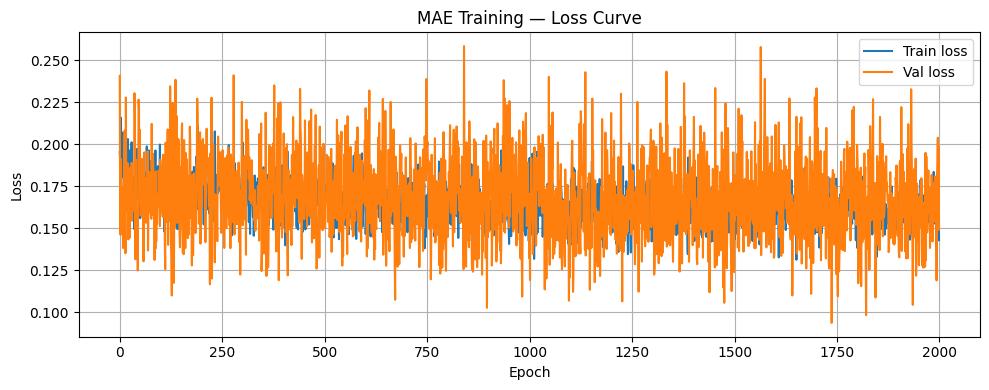

Loss curve saved → loss_curve.png


In [11]:
# =============================================================================
# 8. LOSS CURVE
# =============================================================================
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses,   label="Val loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("MAE Training — Loss Curve")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=120)
plt.show()
print("Loss curve saved → loss_curve.png")